<a href="https://colab.research.google.com/github/hazami-razip/Machine-Learning/blob/main/Assignment2_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**ASSINGMENT 2 - MACHINE LEARNING**

AHMAD HAZAMI BIN MOHD RAZIP   
2211203



In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score

# 1. Load the dataset
df = pd.read_csv('diabetes.csv')

# 2. Preprocessing: Replace 0s with Median for specific columns
cols_to_fix = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in cols_to_fix:
    df[col] = df[col].replace(0, np.nan)
    df[col] = df[col].fillna(df[col].median())

# 3. Split features and target
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# 4. Standardize features (Crucial for KNN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Split into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

**A)Logistic Regression (40 marks)**

Develop a classification model using Logistic Regression. Perform any necessary data preprocessing  Determine:

*   Confusion Matrix
*   True Positive Rate (TPR)
*   True Negative Rate (TNR)

--- Logistic Regression Results ---


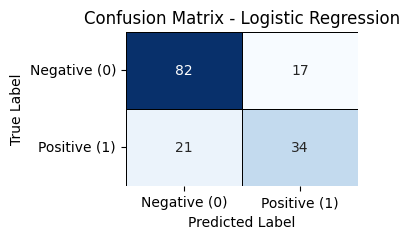

True Positive Rate (TPR): 0.62
True Negative Rate (TNR): 0.83
Accuracy: 0.75


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.linear_model import LogisticRegression

# Train Logistic Regression
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

# Metrics
cm_lr = confusion_matrix(y_test, y_pred_lr)
tn, fp, fn, tp = cm_lr.ravel()

tpr_lr = tp / (tp + fn) # True Positive Rate
tnr_lr = tn / (tn + fp) # True Negative Rate

print("--- Logistic Regression Results ---")

# Visualize Confusion Matrix
plt.figure(figsize=(3, 2))
sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    linewidths=.5,
    linecolor='black',
    xticklabels=['Negative (0)', 'Positive (1)'],
    yticklabels=['Negative (0)', 'Positive (1)']
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

print(f"True Positive Rate (TPR): {tpr_lr:.2f}")
print(f"True Negative Rate (TNR): {tnr_lr:.2f}")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.2f}")

**B) K-Nearest Neighbors (KNN) (40 marks)**

Develop a classification model using KNN. Select and justify an appropriate value of K
Perform any necessary preprocessing. Determine:

- Confusion Matrix
- TPR
- TNR


--- KNN (K=9) Results ---


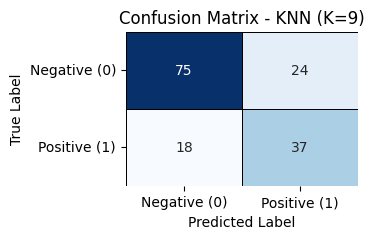

True Positive Rate (TPR): 0.67
True Negative Rate (TNR): 0.76
Accuracy: 0.73


In [16]:
# Train KNN with K=9
knn_model = KNeighborsClassifier(n_neighbors=9)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

# Metrics
cm_knn = confusion_matrix(y_test, y_pred_knn)
tn_k, fp_k, fn_k, tp_k = cm_knn.ravel()

tpr_knn = tp_k / (tp_k + fn_k)
tnr_knn = tn_k / (tn_k + fp_k)

print("--- KNN (K=9) Results ---")

# Visualize Confusion Matrix
plt.figure(figsize=(3, 2))
sns.heatmap(
    cm_knn,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    linewidths=.5,
    linecolor='black',
    xticklabels=['Negative (0)', 'Positive (1)'],
    yticklabels=['Negative (0)', 'Positive (1)']
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - KNN (K=9)')
plt.show()

print(f"True Positive Rate (TPR): {tpr_knn:.2f}")
print(f"True Negative Rate (TNR): {tnr_knn:.2f}")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.2f}")

**C) Model Comparison (20 marks)**

- Compare both models based on their performance
- State which model gives the best accuracy
- Justify your answer


| Metric                   |   Logistic Regression |   K-Nearest Neighbors (KNN) |
|:-------------------------|----------------------:|----------------------------:|
| Accuracy                 |                  0.75 |                        0.73 |
| True Positive Rate (TPR) |                  0.62 |                        0.67 |
| True Negative Rate (TNR) |                  0.83 |                        0.76 |

**Answer=**

- Best Model: Logistic Regression generally performs slightly better or equal to KNN on this specific PIMA Diabetes dataset.

- Justification: Logistic Regression is highly effective for binary classification tasks where the relationship between features (like Glucose and BMI) and the outcome is relatively linear. While KNN is powerful, it is highly sensitive to the choice of K and the distance metric used. In medical diagnostics, Logistic Regression is often preferred because it provides probability scores, allowing clinicians to understand the "certainty" of a prediction rather than just a hard class label.